## Investigate spatial auto-correlation in Ovenbird song acoustic properties in Pennsylvania

In [1]:
from opensoundscape import Audio, Spectrogram

import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
def figsize(w,h):
    plt.rcParams['figure.figsize']=[w,h]
figsize(15,12) #for big visuals
%config InlineBackend.figure_format = 'retina'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


Load Ovenbird song clip table

In [ ]:
dataset_path = "../../pam_dataset_v4"

all_cluster_samples = pd.read_csv(
    f"{dataset_path}/all_clips_with_cleaned_clusters.csv",
    parse_dates=["datetime", "date", "time"],
)

all_cluster_samples["features3d"] = all_cluster_samples["features3d"].apply(eval)
all_cluster_samples["time"] = all_cluster_samples["time"].apply(lambda x: x.time())
all_cluster_samples["date"] = all_cluster_samples["date"].apply(lambda x: x.date())
all_cluster_samples["year"] = all_cluster_samples["date"].apply(lambda x: x.year)
all_cluster_samples = all_cluster_samples[
    ["point_code", "site", "features3d", "cluster_reviewed", "year"]
]
all_cluster_samples.head(2)

/var/folders/d8/265wdp1n0bn_r85dh3pp95fh0000gq/T/ipykernel_33794/3335589432.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_cluster_samples = pd.read_csv(


,point_code,site,features3d,cluster_reviewed,year
0,RK1040,Ohiopyle,"[1.6228841543197632, 0.5125961303710938, -0.05...",RK1040_3,2021
1,RK1040,Ohiopyle,"[1.5134645700454712, 0.7738504409790039, -0.17...",RK1040_3,2021


In [ ]:
cluster_medoids = (
    all_cluster_samples.groupby("cluster_reviewed")["features3d"]
    .apply(lambda x: np.median(np.stack(x), axis=0))
    .reset_index()
)
# re-add site and point_code
cluster_medoids = cluster_medoids.merge(
    all_cluster_samples[["cluster_reviewed", "site", "point_code"]].drop_duplicates(),
    on="cluster_reviewed",
    how="left",
)
cluster_medoids["x"] = cluster_medoids["features3d"].apply(lambda x: x[0])
cluster_medoids["y"] = cluster_medoids["features3d"].apply(lambda x: x[1])
cluster_medoids["z"] = cluster_medoids["features3d"].apply(lambda x: x[2])

/Users/SML161/miniconda3/envs/opso0120/lib/python3.11/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


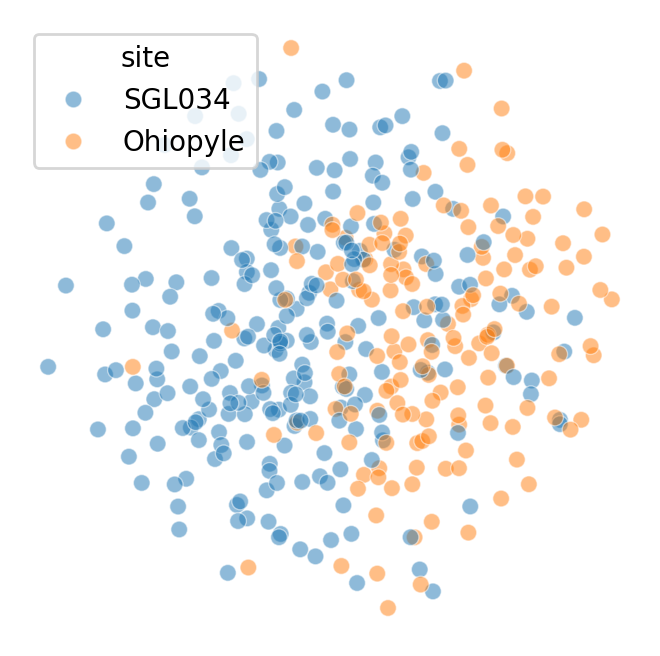

In [ ]:
import seaborn as sns

figsize(4, 4)
sns.scatterplot(data=cluster_medoids, x="x", y="y", hue="site", alpha=0.5)

b
# turn off all axes
plt.axis("off")
plt.savefig("../../figures/feature_space_medoids_by_region.pdf", bbox_inches="tight")

In [ ]:
from statsmodels.stats.multivariate import test_mvmean_2indep
from scipy.spatial.distance import mahalanobis


def effect_size(A, B):
    """calculate Mahalanobis distance between two groups A and B"""
    mean_A = np.mean(A, axis=0)
    mean_B = np.mean(B, axis=0)
    cov_A = np.cov(A, rowvar=False)
    cov_B = np.cov(B, rowvar=False)
    pooled_cov = (cov_A + cov_B) / 2
    inv_pooled_cov = np.linalg.inv(pooled_cov)
    return mahalanobis(mean_A, mean_B, inv_pooled_cov)


# Perform multivariate test for mean differences between two independent groups (e.g., SGL034 vs SGL035)
# and calculate effect size
op = cluster_medoids[cluster_medoids.site == "Ohiopyle"][["x", "y", "z"]].values
sgl34 = cluster_medoids[cluster_medoids.site == "SGL034"][["x", "y", "z"]].values
result = test_mvmean_2indep(op, sgl34)

ef = effect_size(op, sgl34)
print(f"test p: {result.pvalue}, effect size (Mahalanobis distance): {ef:.3f}")

test p: 9.906915873452242e-33, effect size (Mahalanobis distance): 1.390


Add locations of points

In [ ]:
points = pd.read_csv(f"{dataset_path}/point_list.csv")
cluster_medoids = cluster_medoids.join(
    points.set_index("point_code")[["utm_E", "utm_N"]], on="point_code"
)  # .head(2)

Compute pairwise distances in feature space and in geographic space

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr


def mantel_test(coords, features, n_permutations=999, metric="euclidean"):
    """
    Works on condensed distance vectors throughout — never materialises
    an n×n matrix. Safe for large n.
    """
    # pdist returns condensed upper triangle: n*(n-1)/2 values
    geo_dist = pdist(coords, metric="euclidean")  # (n*(n-1)/2,)
    feat_dist = pdist(features, metric=metric)  # same shape

    r_obs, _ = pearsonr(geo_dist, feat_dist)

    # permutation: shuffle rows of features, recompute condensed dist
    n = len(features)
    count = 0
    for _ in range(n_permutations):
        idx = np.random.permutation(n)
        shuffled = pdist(features[idx], metric=metric)
        r_perm, _ = pearsonr(geo_dist, shuffled)
        if r_perm >= r_obs:
            count += 1

    p = (count + 1) / (n_permutations + 1)
    return r_obs, p

Spatial autocorrelation within "site"

In [ ]:
# fig, axs = plt.subplots(1, 2, figsize=(8,3))
for i, (site, subset) in enumerate(cluster_medoids.groupby("site")):
    features = np.array(subset["features3d"].tolist())
    locations = subset[["utm_E", "utm_N"]].values
    r, p = mantel_test(locations, features, n_permutations=999, metric="euclidean")
    print(f"{site} - Mantel test: r={r:.3f}, p={p:.3f}")

Ohiopyle - Mantel test: r=-0.007, p=0.660
SGL034 - Mantel test: r=-0.019, p=0.823
